In [49]:
import numpy as np
import matplotlib.pyplot as plt

设参数$\theta=(\theta_1,\theta_2)^\top$,全量损失为$L_{\text{full}}(\theta)=\theta_1^2+\theta_2^2$

它的全量梯度是
$$
\nabla L_{\text{full}}(\theta)
=
\begin{pmatrix}
2\theta_1\\
2\theta_2
\end{pmatrix}
=
2\theta.
$$

最小值在

$$
\theta^*=(0,0)^\top.
$$

现在把它拆成 $n$ 个样本。例如取 $n=4$，每个样本的损失设为

$$
L_i(\theta)=a_i(\theta_1^2+\theta_2^2),
$$

其中 $a_i>0$，并且满足

$$
\frac1n\sum_{i=1}^n a_i=1.
$$

这样

$$
L_{\text{full}}(\theta)
=
\frac1n\sum_{i=1}^n L_i(\theta)
=
\left(\frac1n\sum_i a_i\right)(\theta_1^2+\theta_2^2)
=
\theta_1^2+\theta_2^2.
$$

单个样本的梯度是

$$
\nabla L_i(\theta)
=
a_i
\begin{pmatrix}
2\theta_1\\
2\theta_2
\end{pmatrix}
=
2a_i\theta.
$$

于是

$$
\mathbb E_{i\sim \text{Uniform}}[\nabla L_i(\theta)]
=
2\left(\frac1n\sum_i a_i\right)\theta
=
2\theta
=
\nabla L_{\text{full}}(\theta).
$$


In [50]:
# 1. 构造样本
n = 10
np.random.seed(0)

b = np.random.uniform(0,10,size=n)
a = b / b.mean()

In [51]:
def sample_grad(theta, i):
    return 2 * a[i] * theta


In [52]:
# ---------- SGD ----------
theta_sgd = np.zeros((T + 1, 2))
theta_sgd[0] = np.array([3.0, -2.0])

g_records = []

for t in range(T):
    i = np.random.randint(n)
    g = sample_grad(theta_sgd[t], i)
    g_records.append(g)

    theta_sgd[t + 1] = theta_sgd[t] - eta * g

g_records = np.array(g_records)

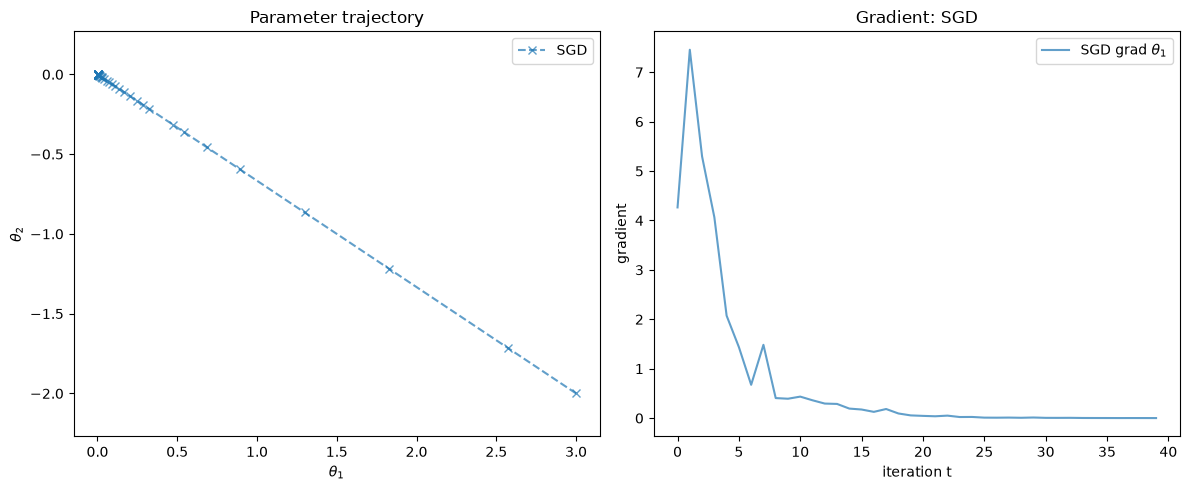

In [53]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(theta_sgd[:, 0], theta_sgd[:, 1], 'x--', alpha=0.7, label='SGD')
plt.xlabel(r'$\theta_1$')
plt.ylabel(r'$\theta_2$')
plt.title('Parameter trajectory')
plt.legend()
plt.axis('equal')

plt.subplot(1, 2, 2)
plt.plot(g_records[:, 0], alpha=0.7, label=r'SGD grad $\theta_1$')
plt.xlabel('iteration t')
plt.ylabel('gradient')
plt.title('Gradient: SGD')
plt.legend()

plt.tight_layout()
plt.show()